<a href="https://colab.research.google.com/github/laurianedlz/Fundamentos-de-Optimizacion/blob/main/Practico_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimizacion sin restriccciones

Sea $f : \mathbb{R}^2 \to \mathbb{R}$ definida por
$$ f(x) = \frac{1}{2} x^T Q x, \quad Q = \begin{pmatrix} 1 & 0 \\ 0 & 50 \end{pmatrix}. $$
Notese que $x^* = \arg \min_{x \in \mathbb{R}^n} f(x) = 0$.


 a)
 * Calcular explícitamente $\nabla f(x)$.

 * ¿Cuál es el número de condición de $Q$? ¿Qué implica esto respecto a la forma de las curvas de nivel de $f$?

$\nabla f(x) = Qx $

El numero de condicion de $ Q$ es $\frac{\lambda_{max}}{\lambda_{min}}=\frac{50}{1}=50$, es muy grande, entonces las curvas de nivel son elongadas : el problema es mal condicionado.

b) Implementar en un notebook los siguientes métodos:
* Descenso por gradiente $$ x_{k+1} = x_k - \alpha \nabla f(x_k). $$
* Método Heavy Ball
$$ x_{k+1} = x_k - \alpha \nabla f(x_k) + \beta(x_k - x_{k-1}). $$
* Método de Nesterov
$$ y_k = x_k + \beta(x_k - x_{k-1}), \quad x_{k+1} = y_k - \alpha \nabla f(y_k). $$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

##Descendo por gradiente

def descendo_por_gradiente(gradiente, x0, alpha, n):
  x=x0
  tray=[x0]
  for i in range(n):
    x = x - alpha * gradiente(x)
    tray.append(x)
  return np.array(tray)

def metodo_heavy_ball(gradiente, x0, x1, alpha, beta, n):
  old_x=x0
  x=x1
  tray=[x0,x1]
  for i in range(n-1):
    fut_x = x - alpha * gradiente(x) + beta * (x - old_x)
    old_x = x
    x = fut_x
    tray.append(fut_x)
  return np.array(tray)

def metodo_nesterov(gradiente, x0, x1, alpha, beta, n):
  old_x=x0
  x=x1
  tray=[x0,x1]
  for i in range(n-1):
    y = x + beta * (x - old_x)
    fut_x = y - alpha * gradiente(y)
    old_x = x
    x = fut_x
    tray.append(fut_x)
  return np.array(tray)


c) Tomar
$$x_0 = (5,5), \quad x_1 = (5,5) \quad (para\space Heavy \space Ball \space y \space Nesterov),$$
$$\alpha = 0,02, \quad \beta = 0,9, $$
y realizar $n = 100$ iteraciones con los tres métodos.

In [14]:
Q = np.array([[1,0],[0,50]])
def gradiente(x):
  return Q@x

x0 = np.array([5,5])
x1 = np.array([5,5])
alpha = 0.02
beta = 0.9
n = 100

desc_grad = descendo_por_gradiente(gradiente, x0, alpha, n)
heavy_ball = metodo_heavy_ball(gradiente, x0, x1, alpha, beta, n)
nesterov = metodo_nesterov(gradiente, x0, x1, alpha, beta, n)

d)
* Graficar en escala logarítmica $\|x_k\|$ en función de $k$.
* Graficar las trayectorias junto con curvas de nivel de $f$.

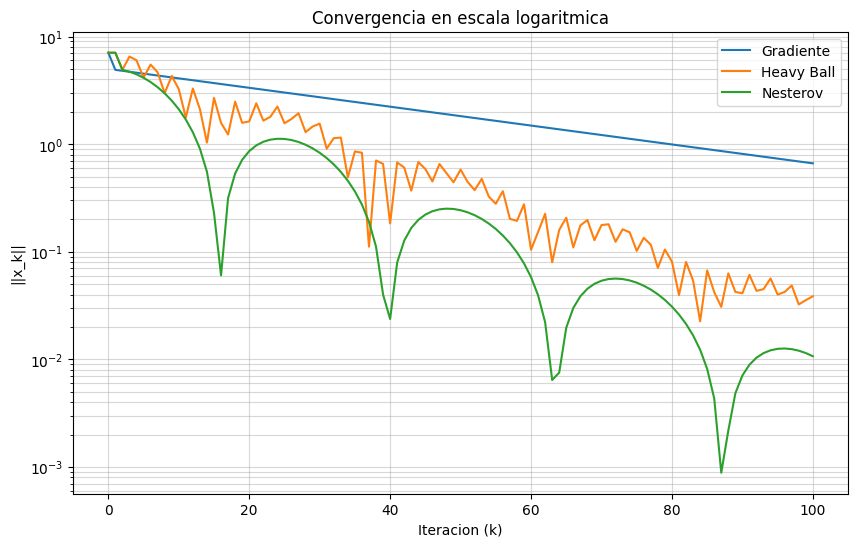

In [15]:
norm_desc_grad = np.linalg.norm(desc_grad, axis=1)
norm_heavy_ball = np.linalg.norm(heavy_ball, axis=1)
norm_nesterov = np.linalg.norm(nesterov, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(norm_desc_grad, label='Gradiente')
plt.plot(norm_heavy_ball, label='Heavy Ball')
plt.plot(norm_nesterov, label='Nesterov')

plt.yscale('log')
plt.xlabel('Iteracion (k)')
plt.ylabel('||x_k||')
plt.title('Convergencia en escala logaritmica')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

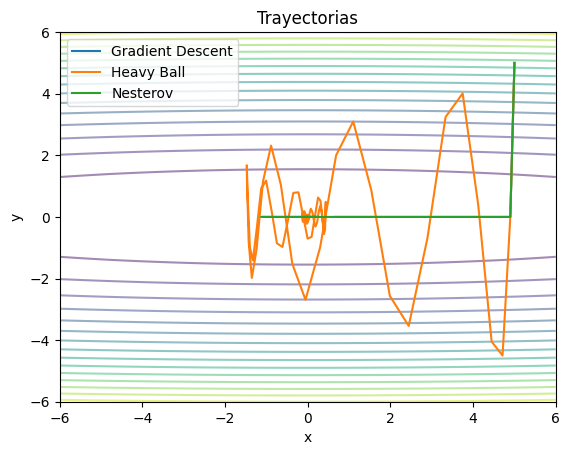

In [16]:
x=np.linspace(-6,6,100)
y=np.linspace(-6,6,100)
X,Y=np.meshgrid(x,y)
Z=(X**2+50*Y**2)/2 ##Cuando developpamos la funcion f
plt.contour(X,Y,Z,15,alpha=0.5)

plt.plot(desc_grad[:, 0], desc_grad[:, 1], label='Gradient Descent') ##Esta escondida debajo de Heavy Ball
plt.plot(heavy_ball[:, 0], heavy_ball[:, 1], label='Heavy Ball')
plt.plot(nesterov[:, 0], nesterov[:, 1], label='Nesterov')
plt.legend()
plt.title('Trayectorias')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


e)
* Comparar la velocidad de convergencia de los tres métodos.
* ¿Se observan oscilaciones? Identificar en qué dirección (asociada a qué autovalor de $Q$).
* Explicar el comportamiento observado en función de la anisotropía del problema (es decir, el cociente entre los valores propios de $Q$).

Podemos ver que el metodo de descendo por gradiente va a tomar mucho mas tiempo que las dos otros porque despues de 100 iteraciones, no esta tan cerca de la solicion como heavy ball y nesterov. Podemos ver tambien que nesterov converge mucho mas rapidamente que neterov porque no oscilla.

Observamos oscilaciones en el eje y solo para heavy ball porque Q tiene un valore propio muy grande (50) por el eje y en comparacion con la del eje x (1). No se pasa eso en neterov porque el gradiente se calculo despues del calculo de y, entonces corrige la trajectoria en este punto directamente y no oscila mucho.

Cuando cambiamos Q y ponemos valores propios mas cerca (cociente mas chico), podemos ver que hay mucho menos oscilaciones.


f)Fijando $\alpha = 0,02$ y los iterados iniciales, repetir el experimento para
$\beta \in \{0, 0.5, 0.9, 0.99\}.$
* Comparar las trayectorias y la velocidad de convergencia.
* Describir qué ocurre cuando $\beta \to 1$.
* Relacionar los resultados con el análisis del caso escalar.

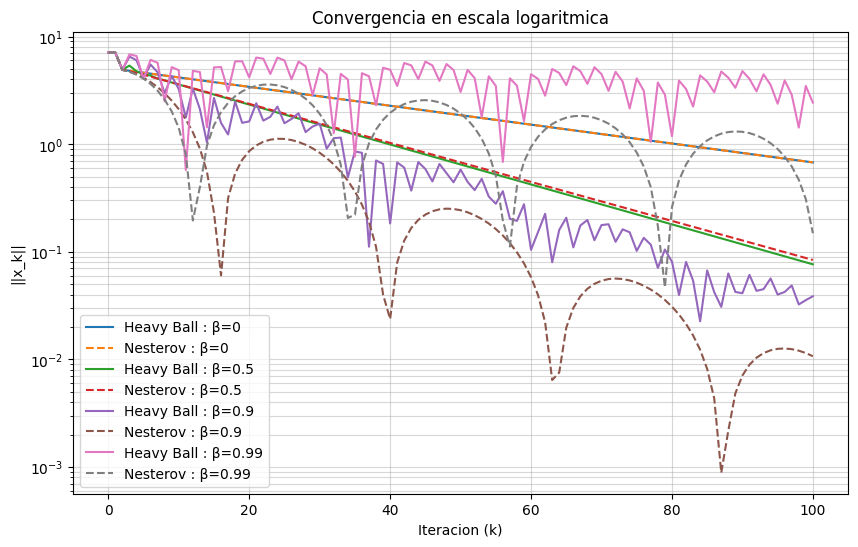

In [23]:
betas = [0,0.5,0.9,0.99]
norm_heavy_ball = []
norm_nesterov = []

for i in range(len(betas)):
  beta = betas[i]
  heavy_ball = metodo_heavy_ball(gradiente, x0, x1, alpha, beta, n)
  nesterov = metodo_nesterov(gradiente, x0, x1, alpha, beta, n)
  norm_heavy_ball.append(np.linalg.norm(heavy_ball, axis=1))
  norm_nesterov.append(np.linalg.norm(nesterov, axis=1))

plt.figure(figsize=(10, 6))

for i in range (len(betas)):
  plt.plot(norm_heavy_ball[i], label=f'Heavy Ball : β={betas[i]}')
  plt.plot(norm_nesterov[i], label=f'Nesterov : β={betas[i]}', linestyle='--')

plt.yscale('log')
plt.xlabel('Iteracion (k)')
plt.ylabel('||x_k||')
plt.title('Convergencia en escala logaritmica')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()


Vemos que cuando β aumenta, la velocidad de convergencia aumenta tambien para los dos metodos. Sin embargo, cuando β→1, la convergencia no esta buena y no baja mucho.